# BRFSS Health Data Analysis

## Exploratory Data Analysis & Statistical Testing

**Author:** Ayush Khanal


## Project Overview

This project explores health survey data using Python to investigate relationships between age, sex, height, current weight and weight from the previous year.

The analysis focuses on data cleaning, exploratory data analysis, descriptive statistics, data visualisation, correlation analysis and statistical hypothesis testing.

### Objectives

- Clean and prepare the dataset
- Explore the main variables
- Calculate descriptive statistics
- Analyse changes in weight
- Investigate relationships between variables
- Perform statistical hypothesis testing
- Visualise and interpret the results

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy
- Google Colab
- Jupyter Notebook

##**Task 1**

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind


In [11]:
df = pd.read_csv('/BRFSS_health_data.csv.csv')
# Display the first few rows of the DataFrame
print(df.head(5))
df.isnull().sum()

   Unnamed: 0   age     weight2     wtyrago   wtkg2   htm3  sex
0           0  39.0   88.636364   88.636364   88.64  180.0    1
1           1  64.0   75.000000   84.545455   75.00  155.0    2
2           2  87.0   61.818182   63.636364   61.82    NaN    2
3           3  51.0  100.000000  100.000000  100.00  183.0    1
4           4  35.0   63.636364   61.363636   63.64  170.0    2


,0
Unnamed: 0,0
age,3653
weight2,16025
wtyrago,24110
wtkg2,16025
htm3,5380
sex,0


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
#handelling the missing value
missing_value=["N/a","NaN","na",np.nan]
df=pd.read_csv("//BRFSS_health_data.csv.csv", na_values=missing_value)
df.isnull().sum()
#filling those missing values by interpolation method
drop_Values=df.interpolate()
print(drop_Values)
df=drop_Values

        Unnamed: 0   age     weight2     wtyrago    wtkg2   htm3  sex
0                0  39.0   88.636364   88.636364   88.640  180.0    1
1                1  64.0   75.000000   84.545455   75.000  155.0    2
2                2  87.0   61.818182   63.636364   61.820  169.0    2
3                3  51.0  100.000000  100.000000  100.000  183.0    1
4                4  35.0   63.636364   61.363636   63.640  170.0    2
...            ...   ...         ...         ...      ...    ...  ...
414504      414504  52.0   88.409091   81.818182   88.405  170.0    2
414505      414505  62.0   86.363636   72.727273   86.360  168.0    2
414506      414506  75.0   59.090909   63.636364   59.090  165.0    2
414507      414507  75.0   59.090909   63.636364   59.090  165.0    2
414508      414508  75.0   59.090909   63.636364   59.090  165.0    2

[414509 rows x 7 columns]


In [14]:
summary_stats = df[['weight2', 'wtyrago', 'htm3']].describe()
print(summary_stats)

             weight2        wtyrago           htm3
count  414509.000000  414509.000000  414509.000000
mean       78.996053      79.716370     168.816775
std        19.371083      20.287978      10.324534
min        20.000000      22.727273      61.000000
25%        65.000000      65.454545     160.000000
50%        77.272727      77.272727     168.000000
75%        90.909091      90.909091     175.000000
max       309.090909     342.272727     236.000000


'weight2', 'wtyrago', 'htm3'=='Current_weight', 'Weight_a_year_ago', 'Height' respectively.

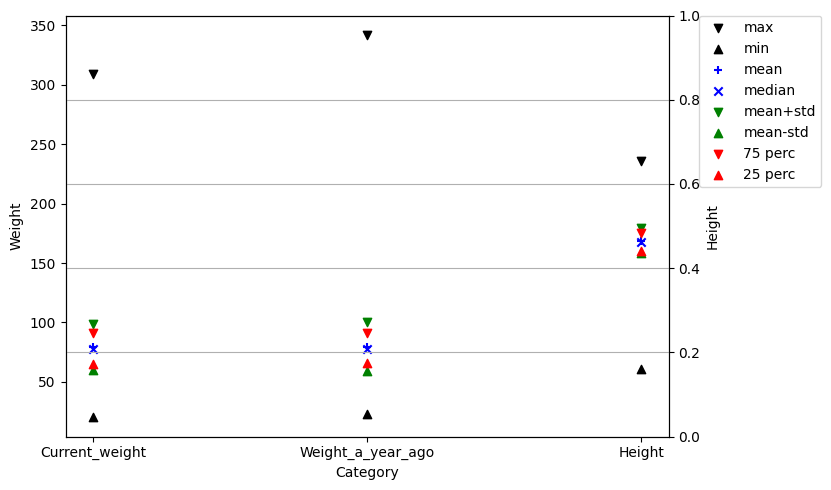

In [15]:
# Plotting categories
categories = ['Current_weight', 'Weight_a_year_ago', 'Height']
x = range(len(categories))

# Calculating statistics
means = [df['weight2'].mean(), df['wtyrago'].mean(), df['htm3'].mean()]
stds = [df['weight2'].std(), df['wtyrago'].std(), df['htm3'].std()]
mean_plus_std = [means[i] + stds[i] for i in range(3)]
mean_minus_std = [means[i] - stds[i] for i in range(3)]
percentile_75 = [df['weight2'].quantile(0.75), df['wtyrago'].quantile(0.75), df['htm3'].quantile(0.75)]
percentile_25 = [df['weight2'].quantile(0.25), df['wtyrago'].quantile(0.25), df['htm3'].quantile(0.25)]
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.scatter(x, [df['weight2'].max(), df['wtyrago'].max(), df['htm3'].max()], marker='v', color='black', label='max')
ax1.scatter(x, [df['weight2'].min(), df['wtyrago'].min(), df['htm3'].min()], marker='^', color='black', label='min')
ax1.scatter(x, means, marker='+', color='blue', label='mean')
ax1.scatter(x, [df['weight2'].median(), df['wtyrago'].median(), df['htm3'].median()], marker='x', color='blue', label='median')
ax1.scatter(x, mean_plus_std, marker='v', color='green', label='mean+std')
ax1.scatter(x, mean_minus_std, marker='^', color='green', label='mean-std')
ax1.scatter(x, percentile_75, marker='v', color='red', label='75 perc')
ax1.scatter(x, percentile_25, marker='^', color='red', label='25 perc')

# creating left y-axis (weight)
ax1.set_ylabel('Weight')
ax1.set_xlabel('Category')
# Creating second y-axis (height)
ax2 = ax1.twinx()
ax2.set_ylabel('Height')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.xticks(x, categories)
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.85, 1])

# Show the plot
plt.show()

##**Task 2**

Correlation between weight_change and current_weight: 0.090418584744012
Correlation between weight_change and weight_a_year_ago: -0.3095137053340958
Correlation between weight_change and age: -0.06981475416482659
Most correlated (absolute value): 0.3095137053340958


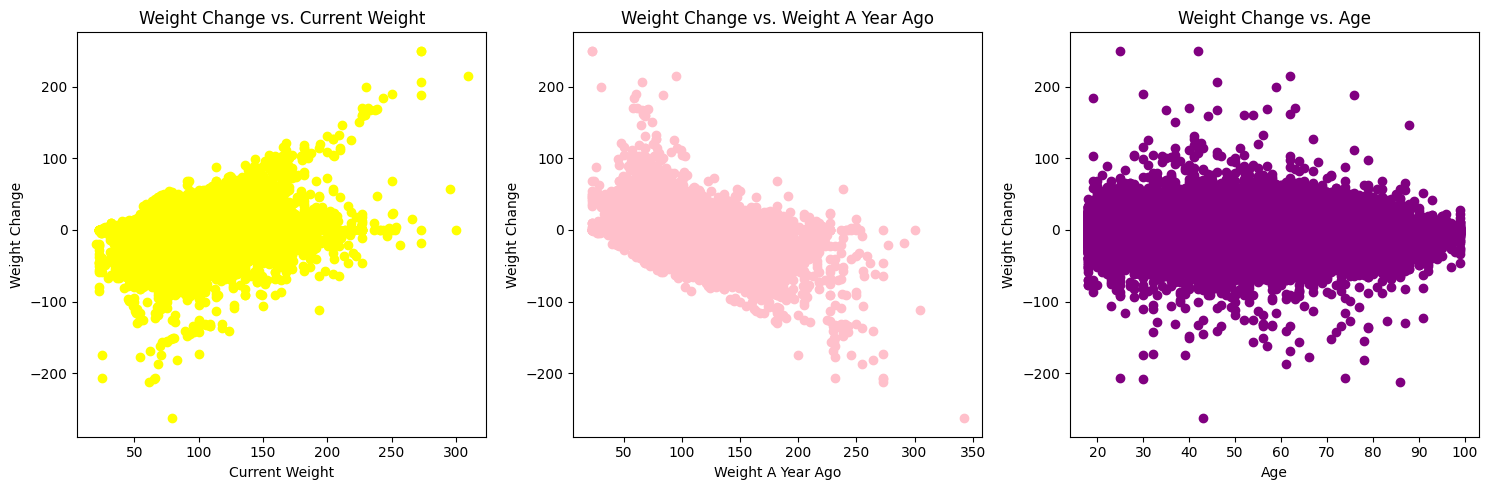

In [16]:
#defining weight change
df['weight_change'] = df['weight2'] - df['wtyrago']

# Calculate Pearson correlations coefficient
corr_current_weight = df['weight_change'].corr(df['weight2'])
corr_weight_a_year_ago = df['weight_change'].corr(df['wtyrago'])
corr_age = df['weight_change'].corr(df['age'])

# Print Pearson correlations coefficient
print(f"Correlation between weight_change and current_weight: {corr_current_weight}")
print(f"Correlation between weight_change and weight_a_year_ago: {corr_weight_a_year_ago}")
print(f"Correlation between weight_change and age: {corr_age}")

# Find maximum  correlated variable (absolute correlation)
most_correlated_var = max(abs(corr_current_weight), abs(corr_weight_a_year_ago), abs(corr_age))
print(f"Most correlated (absolute value): {most_correlated_var}")

# Scatter plots
plt.figure(figsize=(15, 5))

# scatter plot 1: weight_change vs. current_weight
plt.subplot(1, 3, 1)
plt.scatter(df['weight2'], df['weight_change'], color='yellow')
plt.title('Weight Change vs. Current Weight')
plt.xlabel('Current Weight')
plt.ylabel('Weight Change')

# scatter lot 2: weight_change vs. weight_a_year_ago
plt.subplot(1, 3, 2)
plt.scatter(df['wtyrago'], df['weight_change'], color='pink')
plt.title('Weight Change vs. Weight A Year Ago')
plt.xlabel('Weight A Year Ago')
plt.ylabel('Weight Change')

# scatter plot 3: weight_change vs. age
plt.subplot(1, 3, 3)
plt.scatter(df['age'], df['weight_change'], color='purple')
plt.title('Weight Change vs. Age')
plt.xlabel('Age')
plt.ylabel('Weight Change')
plt.tight_layout()

plt.show()


##**Task 3**

T-test result for male vs. female weight change: t-stat=1.6803475579735856, p-value=0.09289046651536481
T-test result for random groups: t-stat=2.1298886727156296, p-value=0.03318139283726442


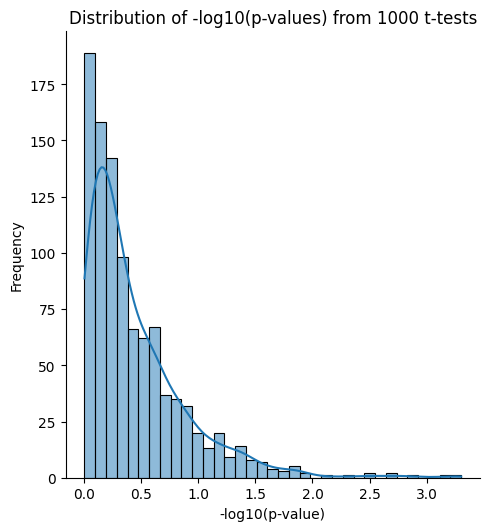

T-test result for male vs. female weight_height_ratio: t-stat=160.6163001698195, p-value=0.0
T-test result for male vs. female weight_change: t-stat=1.6803475579735856, p-value=0.09289046651536481


In [17]:
# Define weight_change
df['weight_change'] = df['weight2'] - df['wtyrago']

# 3.1 T-test: Significant difference between male and female weight_change
male_weight_change = df[df['sex'] == 1]['weight_change']
female_weight_change = df[df['sex'] == 2]['weight_change']
t_stat_sex, p_val_sex =ttest_ind(male_weight_change, female_weight_change, nan_policy='omit')
print(f"T-test result for male vs. female weight change: t-stat={t_stat_sex}, p-value={p_val_sex}")

# 3.2 T-test: Randomly split subjects into two groups and compare weight_change
df['group'] = np.random.randint(0, 2, df.shape[0])  # Randomly assign group 0 or 1
group_0 = df[df['group'] == 0]['weight_change']
group_1 = df[df['group'] == 1]['weight_change']
t_stat_group, p_val_group =ttest_ind(group_0, group_1, nan_policy='omit')
print(f"T-test result for random groups: t-stat={t_stat_group}, p-value={p_val_group}")

# 3.3 Repeat the process 1000 times and plot distribution of -log10(p-value)
p_values = []
for _ in range(1000):
    df['group'] = np.random.randint(0, 2, df.shape[0])  # Randomly assign group 0 or 1
    group_0 = df[df['group'] == 0]['weight_change']
    group_1 = df[df['group'] == 1]['weight_change']
    _, p_val =ttest_ind(group_0, group_1, nan_policy='omit')
    p_values.append(p_val)

# Plot distribution of -log10(p-values)
log_p_values = -np.log10(p_values)
sns.displot(log_p_values, kde=True)
plt.title('Distribution of -log10(p-values) from 1000 t-tests')
plt.xlabel('-log10(p-value)')
plt.ylabel('Frequency')
plt.show()

# 3.4 T-test: Significant difference between male and female weight_height_ratio
df['weight_height_ratio'] = df['weight2'] / df['htm3']
male_ratio = df[df['sex'] == 1]['weight_height_ratio']
female_ratio = df[df['sex'] == 2]['weight_height_ratio']
t_stat_ratio, p_val_ratio =ttest_ind(male_ratio, female_ratio, nan_policy='omit')
print(f"T-test result for male vs. female weight_height_ratio: t-stat={t_stat_ratio}, p-value={p_val_ratio}")

# 3.5 T-test: Repeat analysis from 3.4 with weight_change instead of weight_height_ratio
t_stat_weight_change, p_val_weight_change =ttest_ind(male_weight_change, female_weight_change, nan_policy='omit')
print(f"T-test result for male vs. female weight_change: t-stat={t_stat_weight_change}, p-value={p_val_weight_change}")

##Task 4

#Report

##Title: Exploring BRFSS data

###Introduction
A sizable health-related survey system called the Behavioral Risk Factor Surveillance System (BRFSS) gathers information on the health-related activities, ailments, and services of Americans. This project focuses on analyzing weight and height data, with columns for age, weight, height, gender, and weight from a year ago, among other information. Additionally, this report used hypothesis testing to understand variable-subgroup relationships like gender and correlations. Furthermore, the dataset contains 414509 rows and 7 columns.

The report is divided into multiple sections for study of the data: Using Python visualization tools for data visualization, correlation analysis, statistical differentiating analysis, and summary statistics

###Section 1:summary statistics analysis
**task 1**

The graph provides a statistical overview of three categories such as Current_weight, Weight_a_year_ago, and Height.Current Weight and Weight a Year Ago have a maximum weight of around 320 and a minimum weight around 50.The mean and median weights of both are close to 100, indicating a relatively symmetric distribution around this value. Meanwhile,The standard deviation (mean ± std) suggests that most data points are within around 50 units of the mean.The 25th and 75th percentiles are also near the mean and median, indicating a somewhat normal distribution. futhermore,The height measurements have a maximum around 0.9 meters and a minimum around 0.1 meters.And, The mean and median heights are around 0.5 meters, with standard deviation and percentiles showing a narrow spread.

###Section 2: correlations analysis

**task 2**

In the code above, I used this python code "
df['weight_change'] = df['weight2'] - df['wtyrago']
corr_current_weight = df['weight_change'].corr(df['weight2'])
corr_weight_a_year_ago = df['weight_change'].corr(df['wtyrago'])
corr_age = df['weight_change'].corr(df['age'])
print(f"Correlation between weight_change and current_weight: {corr_current_weight}")
print(f"Correlation between weight_change and weight_a_year_ago: {corr_weight_a_year_ago}")
print(f"Correlation between weight_change and age: {corr_age}") "

This function directly provides the correlation matrix for the selected columns, giving a quick view of how strongly each pair of variables is correlated, ranging from -1 (perfect negative correlation) to 1 (perfect positive correlation)
In the output we can see weight_change and current_weight has positive value 0.090418584744012 means near to perfect correlation where as weight_change and weight_a_year_ago and weight_change and age have negative value such as -0.3095137053340958 and -0.06981475416482659 respectively means near to perfect negative correlation.

### Section 3: Significant difference analysis


**task 3**

T-test result for male vs. female weight change has value t-stat=1.6803475579735856 and p-value=0.09289046651536481, whereas,T-test result for random groups have 1.035605245708108 and 0.3003869478685516 values for T-test and p-value respectively. Aditionally, T-test result for male vs. female weight_height_ratio have t-stat value 160.6163001698195 and p-value 0.0 and T-test result for male vs. female weight_change have t-stat value 1.6803475579735856 and p-value 0.09289046651536481.

###Section 4: Conclusion

**task 4**

summery of the data set determine using this code 'summary_stats = df[['weight2', 'wtyrago', 'htm3']].describe()
print(summary_stats)'

Three variables, including height (htm3), weight (weight2), and weight a year ago (wtyrago), are summarized statistically in the data. People weigh 78.99 kg on average, with a slightly higher weight of 79.72 kg recorded a year ago, indicating a slight decrease in weight. High standard deviations indicate that both weight variables vary significantly. The average height is 168.82 cm, and it varies less than the weight. Overall, the data indicates a stable distribution of heights and some weight variation over time.


